# Tugas - Klasifikasi dengan Support Vector Machine (SVM)

| Nama | NRP |
|------|-----|
| Sulaiman Faiz Tsaqib| 5054251048 |

## Deskripsi Tugas
Pada tugas ini, kalian akan membangun model SVM Classifier untuk menyelesaikan sebuah masalah klasifikasi.

Dataset dapat diakses melalui link berikut:
[Link dataset akan diinformasikan terpisah]

Tujuan utama dari tugas ini adalah memahami cara kerja SVM secara praktik, khususnya:
1. Perbedaan hasil antara kernel Linear dan kernel RBF
2. Pengaruh parameter `C` dan `gamma` terhadap gejala overfitting/underfitting

Langkah-langkah yang harus dilakukan antara lain:
1. Persiapan Dataset dan Eksplorasi Awal
   - Memuat dataset, melihat struktur data, dan distribusi label.
2. Preprocessing
   - Memproses data agar siap digunakan dalam membangun model, termasuk feature scaling.
3. Eksperimen Model
   - Bangun model SVM dengan kernel Linear dan kernel RBF.
   - Lakukan eksperimen regularisasi dengan variasi nilai `C` dan `gamma`.
4. Evaluasi Model
   - Hitung metrik evaluasi dan visualisasikan hasilnya.
5. Analisis dan Kesimpulan
   - Bandingkan hasil eksperimen dan berikan kesimpulan.

# 1. Persiapan Dataset dan Eksplorasi Awal

In [1]:
# Import library yang dibutuhkan (pandas, numpy, matplotlib, seaborn, sklearn, dll)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

In [2]:
# Load dataset dan tampilkan informasi dasar: jumlah baris dan kolom, tipe data, statistik deskriptif, dan jumlah missing value.
df = pd.read_csv('data.csv')
print(df.shape)
df.info()
display(df.describe())
print(df.isnull().sum()[df.isnull().sum() > 0])

(569, 33)
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             56

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


Unnamed: 32    569
dtype: int64


diagnosis
B    357
M    212
Name: count, dtype: int64


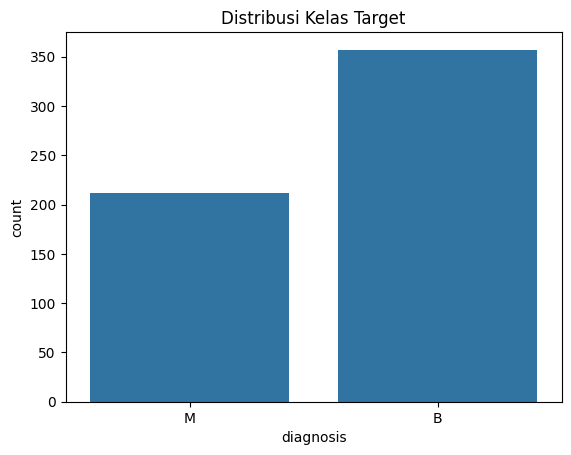

In [3]:
# Tampilkan distribusi kelas target dalam bentuk bar plot.
# Perhatikan apakah dataset ini imbalanced.
print(df['diagnosis'].value_counts())
sns.countplot(x='diagnosis', data=df)
plt.title('Distribusi Kelas Target')
plt.show()

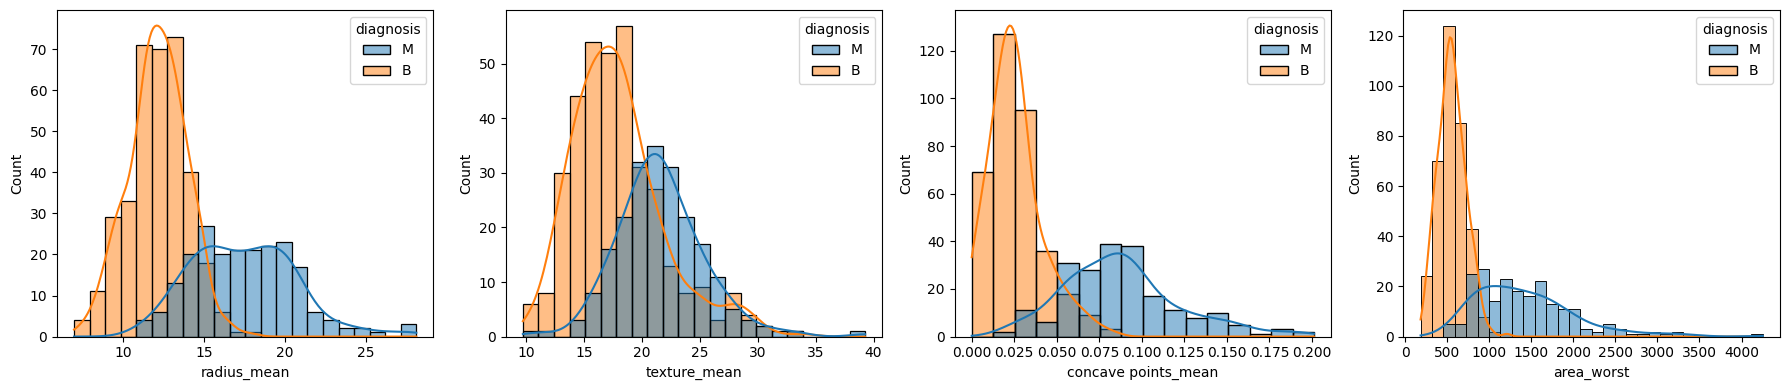

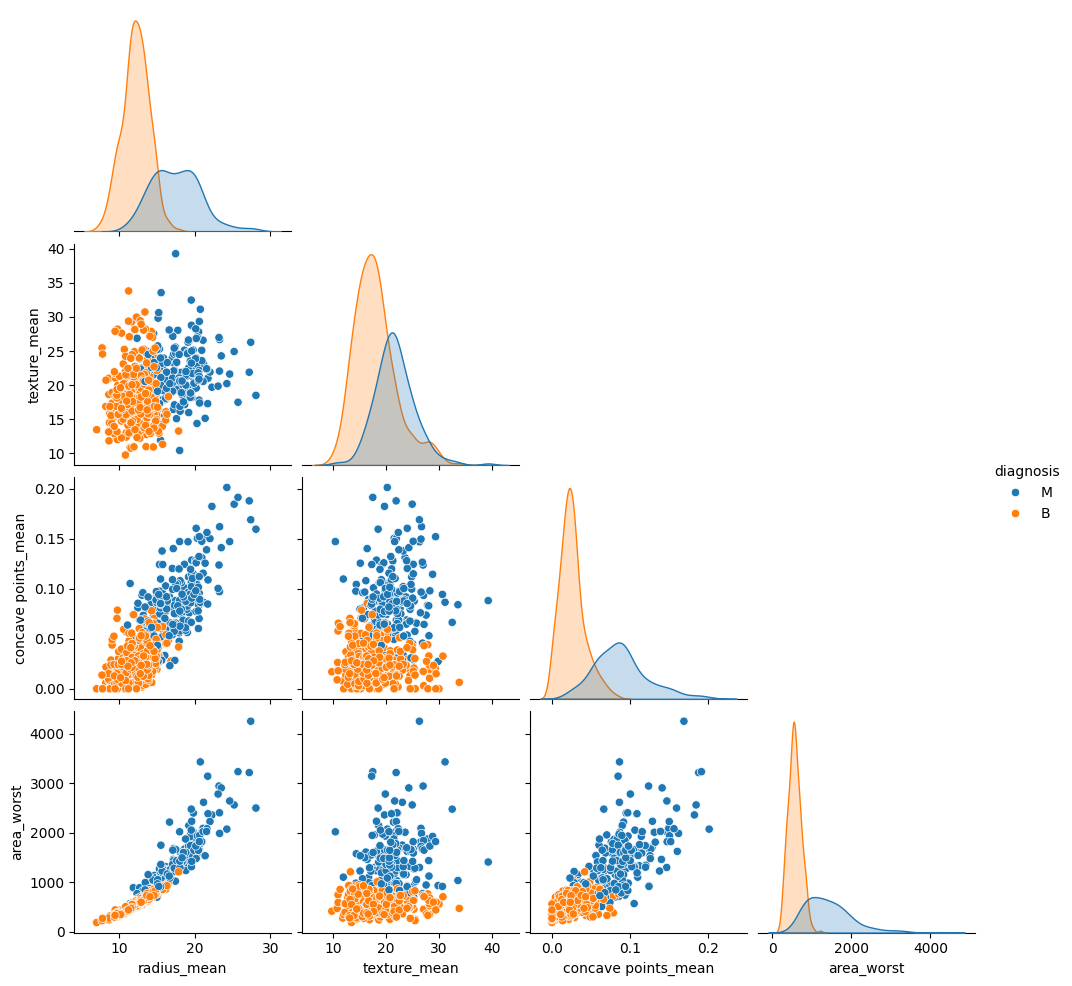

In [4]:
# Tampilkan distribusi atau hubungan antar fitur (histogram, boxplot, atau pairplot), dibedakan berdasarkan kelas target.
# Ini membantu melihat apakah ada fitur yang punya batas pemisah yang jelas (linear) antar kelas, atau justru tumpang tindih.
fitur = ['radius_mean', 'texture_mean', 'concave points_mean', 'area_worst']
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, f in zip(axes, fitur):
    sns.histplot(data=df, x=f, hue='diagnosis', kde=True, ax=ax)
plt.tight_layout()
plt.show()

sns.pairplot(df[fitur + ['diagnosis']], hue='diagnosis', corner=True)
plt.show()

## Lakukan Exploratory Data Analysis (EDA) tambahan yang diperlukan.

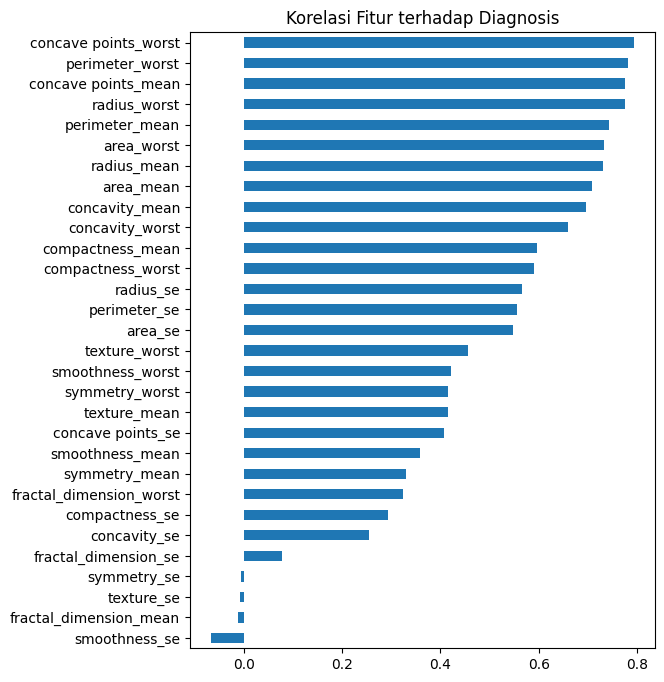

In [5]:
corr = df.drop(columns=['id', 'Unnamed: 32']).assign(diagnosis=df['diagnosis'].map({'B': 0, 'M': 1})).corr()
corr['diagnosis'].drop('diagnosis').sort_values().plot(kind='barh', figsize=(6, 8))
plt.title('Korelasi Fitur terhadap Diagnosis')
plt.show()

# 2. Preprocessing

In [6]:
# Tangani missing value (jika ada) dengan strategi yang sesuai.
# Pastikan strategi yang dipilih tidak memperkenalkan data leakage.
# Kolom 'Unnamed: 32' kosong seluruhnya (akibat koma di akhir header) dan 'id' hanya identitas -> dibuang
df = df.drop(columns=['id', 'Unnamed: 32'])
print(df.isnull().sum().sum())

0


In [7]:
# Jika terdapat fitur kategorikal, lakukan encoding yang sesuai (misalnya One-Hot Encoding atau Ordinal Encoding).
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})
df['diagnosis'].value_counts()

diagnosis
0    357
1    212
Name: count, dtype: int64

In [8]:
# Pisahkan fitur (X) dan target (y).
# Bagi data menjadi train set dan test set (misalnya 80:20).
# Gunakan stratify=y agar distribusi kelas tetap proporsional.
X = df.drop(columns='diagnosis')
y = df['diagnosis']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)
print(X_train.shape, X_test.shape)

(455, 30) (114, 30)


**Catatan penting:** SVM adalah algoritma berbasis jarak (margin dihitung dari posisi antar titik data), sehingga sangat sensitif terhadap skala fitur. Fitur dengan rentang nilai besar bisa mendominasi perhitungan jarak meskipun sebenarnya tidak lebih penting. Lakukan **feature scaling** (misalnya `StandardScaler`) pada fitur numerik sebelum training. Ingat: `fit` scaler hanya pada train set, lalu `transform` ke train dan test set, agar tidak terjadi data leakage.

In [9]:
# Lakukan feature scaling (StandardScaler) pada fitur numerik.
# fit_transform pada X_train, transform saja pada X_test.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. Eksperimen Model

## 3.1 SVM dengan Kernel Linear

Kernel Linear mencari hyperplane pemisah berupa garis/bidang lurus, tanpa proyeksi ke dimensi yang lebih tinggi. Cocok digunakan sebagai baseline, terutama jika dari hasil EDA data terlihat cukup terpisah secara linear.

In [10]:
# Inisialisasi dan latih model SVC dengan kernel='linear' menggunakan train set (yang sudah discaling).
svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)

,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [11]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_linear = svm_linear.predict(X_test)

## 3.2 SVM dengan Kernel RBF

Kernel RBF (Radial Basis Function) memproyeksikan data ke ruang berdimensi lebih tinggi melalui kernel trick, sehingga mampu menangani batas keputusan yang non-linear.

In [12]:
# Inisialisasi dan latih model SVC dengan kernel='rbf' menggunakan train set.
# Gunakan nilai hyperparameter lain (C) yang sama seperti model Linear di atas, agar perbandingan adil.
svm_rbf = SVC(kernel='rbf', C=1, gamma='scale')
svm_rbf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [13]:
# Lakukan prediksi pada test set.
# Simpan hasil prediksi label untuk keperluan evaluasi.
y_pred_rbf = svm_rbf.predict(X_test)

## 3.3 Eksperimen Regularisasi: Pengaruh C dan Gamma terhadap Overfitting

Parameter `C` mengatur trade-off antara margin lebar dan toleransi kesalahan klasifikasi, sedangkan `gamma` (khusus kernel RBF) mengatur seberapa lokal pengaruh tiap titik data. Pada bagian ini kalian akan mengamati bagaimana perubahan nilai `C` (dan/atau `gamma`) memengaruhi akurasi training dan testing.

In [14]:
# Latih beberapa model SVC (kernel RBF) dengan variasi nilai C,
# misalnya 0.01, 0.1, 1, 10, 100.
# Gunakan gamma='scale' atau nilai gamma tetap agar perbandingan fokus pada pengaruh C.
C_values = [0.01, 0.1, 1, 10, 100, 1000]
models = {C: SVC(kernel='rbf', C=C, gamma='scale').fit(X_train, y_train) for C in C_values}

In [15]:
# Hitung akurasi pada train set dan test set untuk setiap nilai C yang dicoba.
# Simpan hasilnya dalam list atau dictionary agar mudah diplot.
train_acc = [accuracy_score(y_train, models[C].predict(X_train)) for C in C_values]
test_acc = [accuracy_score(y_test, models[C].predict(X_test)) for C in C_values]
pd.DataFrame({'C': C_values, 'Train Acc': train_acc, 'Test Acc': test_acc})

,C,Train Acc,Test Acc
0,0.01,0.626374,0.631579
1,0.10,0.953846,0.947368
2,1.00,0.986813,0.973684
3,10.00,0.989011,0.973684
4,100.00,1.000000,0.964912
5,1000.00,1.000000,0.964912


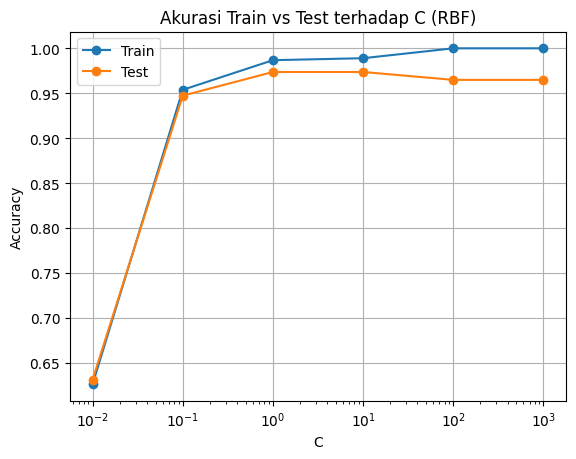

In [16]:
# Plot grafik akurasi training vs testing terhadap nilai C (gunakan sumbu x logaritmik) dalam satu chart.
# Amati pada nilai C berapa model mulai menunjukkan gejala overfitting
# (akurasi training terus naik, sementara akurasi testing mulai stagnan atau menurun).
plt.plot(C_values, train_acc, 'o-', label='Train')
plt.plot(C_values, test_acc, 'o-', label='Test')
plt.xscale('log')
plt.xlabel('C')
plt.ylabel('Accuracy')
plt.title('Akurasi Train vs Test terhadap C (RBF)')
plt.legend()
plt.grid(True)
plt.show()

# 4. Evaluasi Model

In [17]:
# Tampilkan metrik evaluasi (Accuracy, Precision, Recall, F1-Score) untuk model kernel Linear dan RBF.
# Sajikan dalam satu tabel perbandingan agar mudah dibandingkan.
def metrik(y_true, y_pred):
    return [accuracy_score(y_true, y_pred), precision_score(y_true, y_pred),
            recall_score(y_true, y_pred), f1_score(y_true, y_pred)]

pd.DataFrame({'Linear': metrik(y_test, y_pred_linear), 'RBF': metrik(y_test, y_pred_rbf)},
             index=['Accuracy', 'Precision', 'Recall', 'F1-Score']).T

,Accuracy,Precision,Recall,F1-Score
Linear,0.964912,1.0,0.904762,0.950000
RBF,0.973684,1.0,0.928571,0.962963


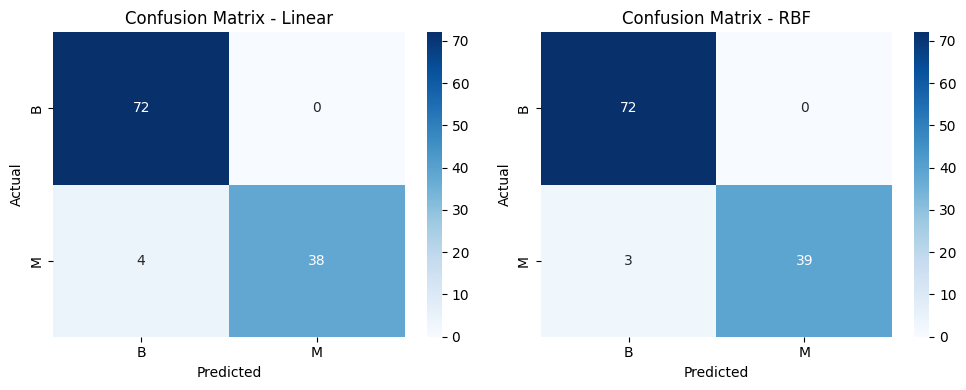

In [18]:
# Tampilkan Confusion Matrix untuk model kernel Linear dan RBF dalam bentuk heatmap.
# Susun keduanya dalam satu baris subplot.
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (nama, pred) in zip(axes, [('Linear', y_pred_linear), ('RBF', y_pred_rbf)]):
    sns.heatmap(confusion_matrix(y_test, pred), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['B', 'M'], yticklabels=['B', 'M'])
    ax.set_title(f'Confusion Matrix - {nama}')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

In [19]:
# Tampilkan jumlah support vectors dari model dengan performa terbaik (atribut model.support_vectors_ atau model.n_support_).
# Bandingkan jumlah support vectors antara model Linear dan RBF.
print('Linear - n_support per kelas:', svm_linear.n_support_, '| total:', svm_linear.n_support_.sum())
print('RBF    - n_support per kelas:', svm_rbf.n_support_, '| total:', svm_rbf.n_support_.sum())

Linear - n_support per kelas: [19 19] | total: 38
RBF    - n_support per kelas: [50 57] | total: 107


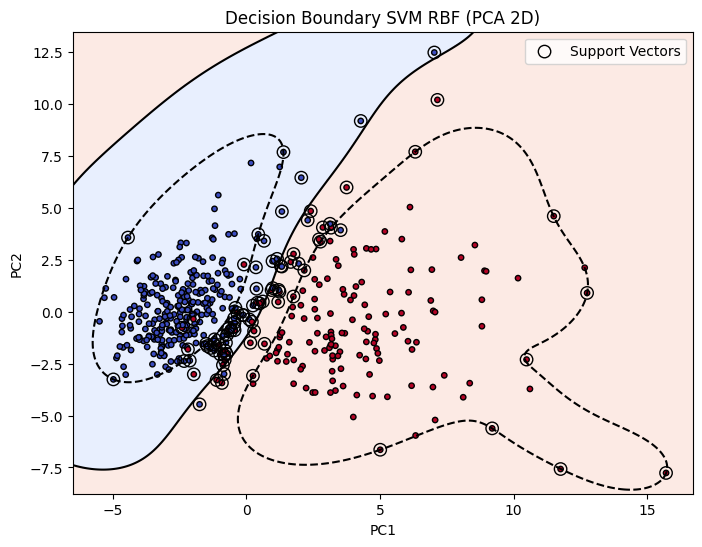

In [20]:
# Jika memungkinkan, pilih dua fitur (atau reduksi dimensi dengan PCA ke 2D) lalu visualisasikan decision boundary
# beserta margin dan support vectors dari model terbaik.
# Reduksi ke 2D dengan PCA, lalu latih ulang SVM RBF (C=1) khusus untuk visualisasi
pca = PCA(n_components=2)
X_train_2d = pca.fit_transform(X_train)
model_2d = SVC(kernel='rbf', C=1, gamma='scale').fit(X_train_2d, y_train)

xx, yy = np.meshgrid(np.linspace(X_train_2d[:, 0].min() - 1, X_train_2d[:, 0].max() + 1, 300),
                     np.linspace(X_train_2d[:, 1].min() - 1, X_train_2d[:, 1].max() + 1, 300))
Z = model_2d.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z > 0, alpha=0.2, cmap='coolwarm')
plt.contour(xx, yy, Z, levels=[-1, 0, 1], colors='k', linestyles=['--', '-', '--'])
plt.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap='coolwarm', s=15, edgecolors='k')
sv = model_2d.support_vectors_
plt.scatter(sv[:, 0], sv[:, 1], s=80, facecolors='none', edgecolors='k', label='Support Vectors')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Decision Boundary SVM RBF (PCA 2D)')
plt.legend()
plt.show()

# 5. Analisis

### Jelaskan secara detail hasil analisis yang didapatkan dari eksperimen yang telah dilakukan.

Beberapa hal yang perlu dibahas:
- Bandingkan performa SVM dengan kernel Linear vs RBF. Apakah hasilnya berbeda signifikan? Menurut kalian, kenapa demikian, dikaitkan dengan bentuk sebaran data pada EDA?
- Jelaskan temuan dari eksperimen regularisasi (nilai `C`). Pada nilai berapa model mulai menunjukkan gejala overfitting? Bagaimana ciri-cirinya terlihat dari grafik akurasi training vs testing?
- Bandingkan jumlah support vectors antara model Linear dan RBF. Apa hubungan jumlah support vectors dengan kompleksitas batas keputusan yang terbentuk?

Pastikan analisis didasari oleh hasil eksperimen sendiri yang telah dilakukan, bukan hasil orang lain.

**Linear vs RBF.** Kedua kernel memberikan performa yang sangat mirip: Linear (Accuracy 96.5%, Recall 90.5%, F1 0.950) dan RBF (Accuracy 97.4%, Recall 92.9%, F1 0.963). Precision keduanya 1.0, artinya tidak ada tumor jinak (B) yang diprediksi ganas (M). Perbedaannya hanya 1 sampel pada test set (RBF salah 3, Linear salah 4, semuanya kasus M yang terprediksi B), sehingga tidak signifikan. Hal ini sesuai dengan hasil EDA: fitur seperti radius_mean, concave points_mean, dan area_worst sudah memisahkan kelas B dan M dengan cukup jelas (histogram hanya sedikit tumpang tindih dan korelasinya tinggi terhadap diagnosis), sehingga data hampir terpisah secara linear dan kernel RBF hanya memberi sedikit keuntungan di daerah perbatasan.

**Eksperimen regularisasi (C).** Pada C=0.01 model mengalami *underfitting* berat (train 62.6%, test 63.2%; model praktis menebak kelas mayoritas). Akurasi naik tajam pada C=0.1 (95.4% / 94.7%) dan mencapai puncak test pada C=1 dan C=10 (97.4%). Mulai C=100 model menunjukkan gejala *overfitting*: akurasi train mencapai 100% sementara akurasi test justru turun ke 96.5%. Pada grafik, cirinya terlihat dari kurva train yang terus naik hingga 1.0 sedangkan kurva test stagnan lalu menurun, sehingga celah antara train dan test melebar. C besar membuat model hampir tidak menoleransi kesalahan, sehingga margin menyempit dan model menghafal noise di data latih.

**Support vectors.** Model Linear hanya membutuhkan 38 support vectors (19 per kelas), sedangkan RBF membutuhkan 107 (50 B, 57 M). Jumlah support vector yang lebih banyak menandakan batas keputusan yang lebih kompleks/fleksibel: RBF membentuk boundary melengkung yang ditentukan oleh banyak titik lokal, sementara Linear cukup didefinisikan oleh sedikit titik di sekitar satu hyperplane. Karena data hampir linear separable, model Linear sudah memadai dengan kompleksitas yang jauh lebih rendah.

# 6. Kesimpulan dan Saran

### Berikan kesimpulan dari eksperimen yang telah dilakukan.

Saran dapat berupa rekomendasi untuk eksperimen selanjutnya (misalnya mencoba kernel Polynomial, melakukan hyperparameter tuning dengan GridSearchCV, atau membandingkan dengan model lain), perbaikan model, atau hal-hal lain yang relevan dengan tugas ini.

**Kesimpulan:**
1. SVM mencapai akurasi test ~97% setelah feature scaling.
2. RBF (97.4%) sedikit lebih baik dari Linear (96.5%), selisihnya kecil karena data hampir terpisah secara linear.
3. C terlalu kecil (0.01) menyebabkan underfitting, C=1–10 optimal, dan C ≥ 100 mulai overfitting.
4. Linear jauh lebih sederhana (38 vs 107 support vectors) dengan performa hampir setara.

**Saran:**
- Tuning C dan gamma dengan GridSearchCV.
- Gunakan class_weight='balanced untuk menaikkan Recall kelas ganas.